# CatBoost Classifier - PS-S06E09: Electric Vehicle Purchases

This notebook trains a **CatBoost Classifier** model for Kaggle Playground Series Season 6 Episode 9, predicting the binary target `Will_Buy_EV` (`Yes` / `No`).

Key features:
* **Shared Utilities**: Leverages `ExperimentSetup`, `FeatureFactory`, and `ModelVisualizer`.
* **SQLite-Backed Optuna Persistence**: Hyperparameters tuned via Optuna with persistent SQLite storage (`catboost_study.db`).
* **Fold Cache Pattern**: Features engineered once per fold and cached for fast Optuna evaluation.
* **Multi-Seed Ensembling**: Models evaluated across 5 stratified folds and multiple random seeds.
* **Prediction Export**: Probabilities saved for downstream model ensembling and blending.

## 1. Setup & Imports

In [1]:
import os
import gc
import sys
import json
import math
import time
import random
import warnings
from pathlib import Path
from typing import Iterable

import numpy as np
import pandas as pd
import catboost as cb
import optuna
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

from ps_s06e09_experiment_setup import ExperimentSetup
from ps_s06e09_feature_engineering import FeatureFactory
from ps_s06e09_model_visualizer import ModelVisualizer

# --- Notebook settings
warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
setup = ExperimentSetup(
    model_name='CatBoost',
    use_gpu=True,
    perform_optuna_tuning=False
)

seed = setup.set_seeds()
setup.configure_pandas()
setup.suppress_warnings()

TARGET = 'Will_Buy_EV'

Random seed set to: 10301
Warnings suppressed.


## 2. Load Datasets

In [3]:
training_df = setup.read_dataset('training')
train_ids = training_df['id'].copy()

test_df = setup.read_dataset('test')
test_ids = test_df['id'].copy()

TRAINING DATASET

   id  Age  Annual_Income_USD  Daily_Commute_km  Number_of_Cars_Owned  \
0   0   66         92,887.000            23.400                     2   
1   1   38         30,000.000             5.000                     1   
2   2   26         94,389.000            36.800                     1   
3   3   66         73,580.000            23.700                     2   
4   4   54         57,898.000            50.800                     1   

   Charging_Stations_Near_Home  Charging_Stations_Near_Work  \
0                            3                            7   
1                            2                            2   
2                            8                           15   
3                            6                            9   
4                            2                            3   

   Environmental_Concern_Level  Gender City_Type Current_Car_Type  \
0                        1.000    Male  Suburban            Sedan   
1                        4

## 3. Feature Engineering

In [4]:
fe_strategies = [
    'encoding',
    'ev_ratios',
    'charging_accessibility',
    'financial_incentives',
    'range_anxiety_interactions',
    'buyer_readiness_score',
    'digit_decomposition',
    'synthetic_spikes_boundaries',
    'subsidy_interactions',
]

ff = FeatureFactory(strategies=fe_strategies, verbose=True)
X = ff.fit_transform(training_df)
y = training_df[TARGET].map({'Yes': 1, 'No': 0})

X_test = ff.transform(test_df)

# True nominal categories passed to CatBoost cat_features
cat_cols = ['Gender', 'City_Type', 'Current_Car_Type']
for c in cat_cols:
    if c in X.columns:
        X[c] = X[c].astype(str)
        X_test[c] = X_test[c].astype(str)

# Convert ordinal categoricals to numeric floats for exact split thresholding
ordinal_map = {
    'Range_Anxiety_Level': {'Low': 0, 'Medium': 1, 'High': 2},
    'Home_Charging_Possible': {'No': 0, 'Yes': 1},
    'Subsidy_Available': {'No': 0, 'Yes': 1}
}
for col, mapping in ordinal_map.items():
    if col in X.columns:
        X[col] = X[col].astype(str).map(mapping).fillna(0).astype(float)
        X_test[col] = X_test[col].astype(str).map(mapping).fillna(0).astype(float)

print(f'Nominal Categorical features for CatBoost: {cat_cols}')
print(f'Engineered Train shape: {X.shape}')
print(f'Engineered Test shape:  {X_test.shape}')

  -> Fitting DataFrame...
Applying FeatureFactory with strategies: encoding, ev_ratios, charging_accessibility, financial_incentives, range_anxiety_interactions, buyer_readiness_score, digit_decomposition, synthetic_spikes_boundaries, subsidy_interactions
  -> Encoding categorical variables...
  -> Adding EV ratio features...
  -> Adding charging accessibility features...
  -> Adding financial incentive features...
  -> Adding range anxiety interaction features...
  -> Adding buyer readiness score features...
  -> Adding digit decomposition features...
  -> Adding synthetic spikes and boundary features...
  -> Adding subsidy interaction features...
Applying FeatureFactory with strategies: encoding, ev_ratios, charging_accessibility, financial_incentives, range_anxiety_interactions, buyer_readiness_score, digit_decomposition, synthetic_spikes_boundaries, subsidy_interactions
  -> Encoding categorical variables...
  -> Adding EV ratio features...
  -> Adding charging accessibility featur

## 4. Hyperparameter Tuning (Optuna + SQLite Storage)

In [5]:
optuna_filename = 'optuna_params_catboost.json'
best_params = setup.load_optuna_params(optuna_filename)

if setup.perform_optuna_tuning():
    print('Starting Optuna hyperparameter optimization for CatBoost...')

    # Fold Cache Pattern
    skf_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    fold_cache = []
    for tr_idx, val_idx in skf_cv.split(X, y):
        fold_cache.append((
            X.iloc[tr_idx].copy(),
            X.iloc[val_idx].copy(),
            y.iloc[tr_idx].copy(),
            y.iloc[val_idx].copy()
        ))

    def objective(trial):
        params = {
            'loss_function': 'Logloss',
            'eval_metric': 'AUC',
            'metric_period': 5,
            'task_type': 'GPU' if setup.use_gpu() else 'CPU',
            'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.1, log=True),
            'depth': trial.suggest_int('depth', 4, 8),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 30.0, log=True),
            'random_strength': trial.suggest_float('random_strength', 0.1, 10.0, log=True),
            'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
            'border_count': trial.suggest_int('border_count', 128, 254),
            'iterations': 2500,
            'random_seed': seed,
            'verbose': False
        }

        scores = []
        for fold_idx, (X_tr, X_val, y_tr, y_val) in enumerate(fold_cache):
            model = cb.CatBoostClassifier(**params, cat_features=cat_cols, early_stopping_rounds=100)
            model.fit(X_tr, y_tr, eval_set=(X_val, y_val), verbose=False)
            val_preds = model.predict_proba(X_val)[:, 1]
            score = roc_auc_score(y_val, val_preds)
            scores.append(score)

        return np.mean(scores)

    sampler = optuna.samplers.TPESampler(multivariate=True, seed=seed)
    study = optuna.create_study(
        study_name='catboost_tuning_v15',
        storage='sqlite:///catboost_study.db',
        pruner=optuna.pruners.NopPruner(),
        load_if_exists=True,
        direction='maximize',
        sampler=sampler
    )

    # Known good baseline trial
    if best_params is None:
        best_params = {
            'learning_rate': 0.05,
            'depth': 6,
            'l2_leaf_reg': 5.0,
            'random_strength': 1.0,
            'bagging_temperature': 0.5
        }
    study.enqueue_trial(best_params)

    study.optimize(
        objective,
        n_trials=30,
        timeout=7200,
        show_progress_bar=True
    )

    print(f'Best Trial ROC AUC: {study.best_value:.6f}')
    best_params = study.best_params
    setup.save_optuna_params(optuna_filename, best_params)
    setup.upload_artifact(optuna_filename)
else:
    print('Using default or cached CatBoost parameters.')

Loaded 6 parameters from optuna_params_catboost.json
Using default or cached CatBoost parameters.


In [6]:
try:
    fig = optuna.visualization.plot_optimization_history(study)
    fig.show()
except NameError:
    print("Optuna wasn't run")

Optuna wasn't run


## 5. Model Training & Multi-Seed Blending

In [7]:
seeds = setup.seed()
oof_probs = np.zeros((len(X), 2))
test_probs = np.zeros((len(X_test), 2))
filled_mask = np.ones(len(X), dtype=bool)

models = []
eval_results = []
seed_scores = {}

base_params = {
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'metric_period': 5,
    'task_type': 'GPU' if setup.use_gpu() else 'CPU',
    'iterations': 2000,
    'verbose': False,
    **best_params
}

for current_seed in seeds:
    print(f'\n--- Training CatBoost across 5 Folds with Seed {current_seed} ---')
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=current_seed)
    seed_oof = np.zeros(len(X))

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
        
        model = cb.CatBoostClassifier(**base_params, cat_features=cat_cols, random_seed=current_seed, early_stopping_rounds=100)
        model.fit(
            X_tr, y_tr,
            eval_set=(X_val, y_val),
            verbose=False
        )
        
        val_pred_prob = model.predict_proba(X_val)
        seed_oof[val_idx] = val_pred_prob[:, 1]
        
        oof_probs[val_idx, 0] += val_pred_prob[:, 0] / len(seeds)
        oof_probs[val_idx, 1] += val_pred_prob[:, 1] / len(seeds)
        
        test_pred_prob = model.predict_proba(X_test)
        test_probs[:, 0] += test_pred_prob[:, 0] / (len(seeds) * 5)
        test_probs[:, 1] += test_pred_prob[:, 1] / (len(seeds) * 5)
        
        models.append(model)
        eval_results.append(model.get_evals_result())
        
        fold_auc = roc_auc_score(y_val, val_pred_prob[:, 1])
        print(f'Seed {current_seed} | Fold {fold+1} ROC AUC: {fold_auc:.6f}')
        
    seed_auc = roc_auc_score(y, seed_oof)
    seed_scores[current_seed] = seed_auc
    print(f'>>> Seed {current_seed} OOF ROC AUC: {seed_auc:.6f}')

print('\n==========================================')
for s, score in seed_scores.items():
    print(f'Seed {s:<5} OOF ROC AUC: {score:.6f}')
overall_auc = roc_auc_score(y, oof_probs[:, 1])
print('------------------------------------------')
print(f'Overall Multi-Seed OOF ROC AUC: {overall_auc:.6f}')
print('==========================================')


--- Training CatBoost across 5 Folds with Seed 10301 ---
Seed 10301 | Fold 1 ROC AUC: 0.942328
Seed 10301 | Fold 2 ROC AUC: 0.943696
Seed 10301 | Fold 3 ROC AUC: 0.943986
Seed 10301 | Fold 4 ROC AUC: 0.942817
Seed 10301 | Fold 5 ROC AUC: 0.944362
>>> Seed 10301 OOF ROC AUC: 0.943432

--- Training CatBoost across 5 Folds with Seed 42 ---
Seed 42 | Fold 1 ROC AUC: 0.942088
Seed 42 | Fold 2 ROC AUC: 0.943309
Seed 42 | Fold 3 ROC AUC: 0.944429
Seed 42 | Fold 4 ROC AUC: 0.943761
Seed 42 | Fold 5 ROC AUC: 0.943360
>>> Seed 42 OOF ROC AUC: 0.943383

--- Training CatBoost across 5 Folds with Seed 2026 ---
Seed 2026 | Fold 1 ROC AUC: 0.942746
Seed 2026 | Fold 2 ROC AUC: 0.942513
Seed 2026 | Fold 3 ROC AUC: 0.944698
Seed 2026 | Fold 4 ROC AUC: 0.943309
Seed 2026 | Fold 5 ROC AUC: 0.943403
>>> Seed 2026 OOF ROC AUC: 0.943330

--- Training CatBoost across 5 Folds with Seed 777 ---
Seed 777 | Fold 1 ROC AUC: 0.943971
Seed 777 | Fold 2 ROC AUC: 0.943553
Seed 777 | Fold 3 ROC AUC: 0.942692
Seed 777 

## 6. Performance Visualization

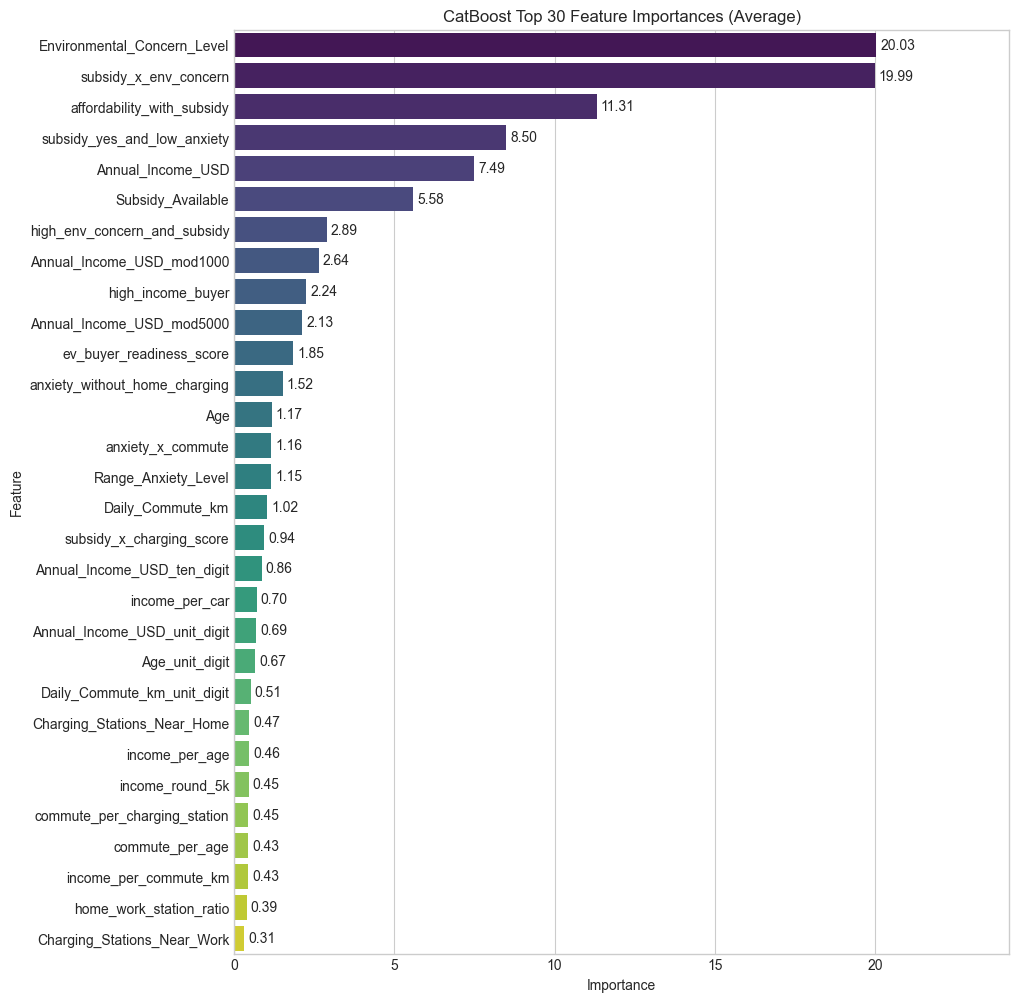

In [8]:
mviz = ModelVisualizer(model_name='CatBoost')
mviz.plot_feature_importance(models[:5], show_values=True)

<Figure size 800x600 with 0 Axes>

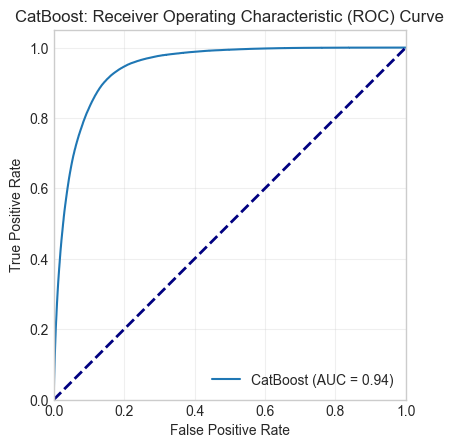

In [9]:
mviz.plot_roc_curve(y_true=y, y_score=oof_probs[:, 1])

Confusion matrix, without normalization


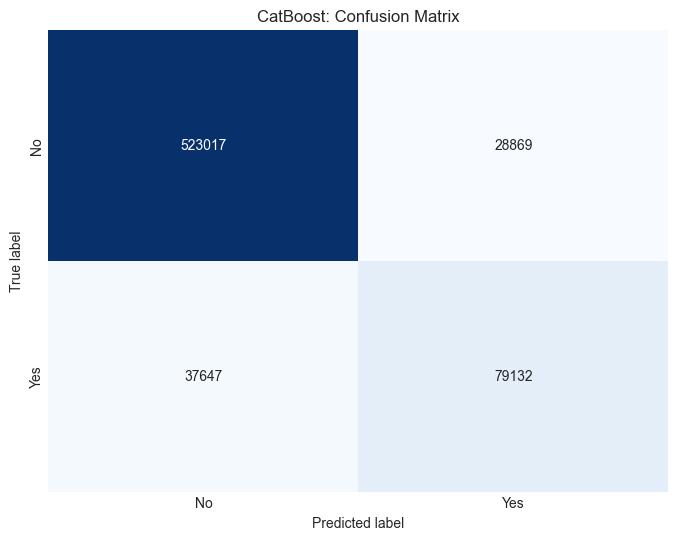

In [10]:
y_pred_class = (oof_probs[:, 1] >= 0.5).astype(int)
mviz.plot_confusion_matrix(y_true=y, y_pred=y_pred_class, classes=['No', 'Yes'])

## 7. Export Submission & Predictions

In [11]:
submission_df = setup.read_dataset('submission')
submission_df[TARGET] = test_probs[:, 1]
submission_df.to_csv('submission.csv', index=False)
print('Saved submission.csv successfully!')

setup.save_probabilities('catboost', oof_probs, train_ids, y, filled_mask, test_probs, test_ids)

Saved submission.csv successfully!
Saved for ensembling:
 - predictions/catboost_oof_probs.csv
 - predictions/catboost_test_probs.csv
